# **Swigy Sales Analysis**

**Importing required libraries** **:**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

**Importing the dataset :**

In [2]:
df=pd.read_excel("/content/swiggy_data.xlsx")

In [3]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [4]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


**Metadata of Data :**

In [5]:
print("No of rows:",df.shape[0])

No of rows: 197430


In [6]:
print("No of columns:",df.shape[1])

No of columns: 10


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


**Data types :**

In [8]:
df.dtypes

,0
State,object
City,object
Order Date,datetime64[ns]
Restaurant Name,object
Location,object
Category,object
Dish Name,object
Price (INR),float64
Rating,float64
Rating Count,int64


In [9]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


# **KPI's**

**Total Sales :**

In [10]:
total_sales=df["Price (INR)"].sum()
print("Total Sales:",round(total_sales,2))

Total Sales: 53012505.77


**Average Rating:**

In [11]:
avg_rating=df['Rating'].mean()
print("Average Rating:",round(avg_rating,2))

Average Rating: 4.34


**Ratings Count :**

In [12]:
rating_count= df['Rating'].sum()
print("Rating Count:",rating_count)

Rating Count: 857158.5


**Average Order Value**

In [13]:
avg_order= df["Price (INR)"].mean()
print("Average order:",round(avg_order,2))

Average order: 268.51


**Total Orders:**

In [14]:
print("Total Orders:",len(df))

Total Orders: 197430


# **Charts**

**Monthly Sales Trend**

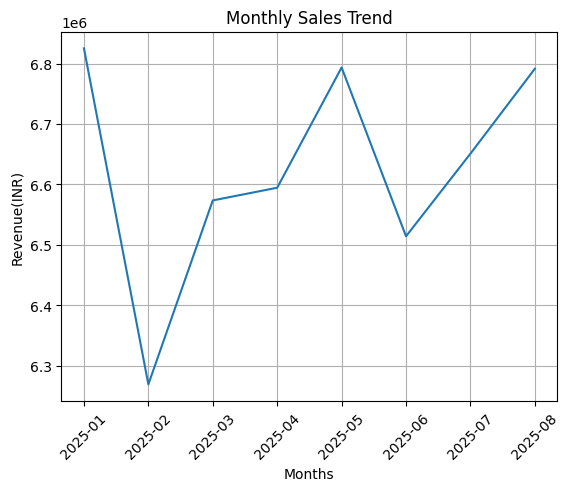

In [15]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)
monthly_revenue = df.groupby("YearMonth")["Price (INR)"].sum().reset_index()

plt.figure()
plt.plot(monthly_revenue["YearMonth"],monthly_revenue["Price (INR)"])
plt.xticks(rotation=45)
plt.xlabel("Months")
plt.ylabel("Revenue(INR)")
plt.title("Monthly Sales Trend")
plt.grid()
plt.show()

**Daily Sales Trend**

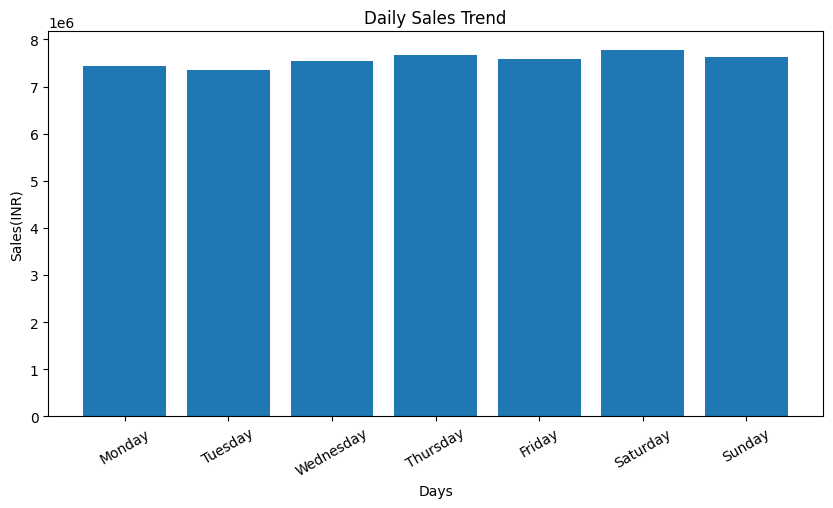

In [16]:
df["DayName"] = pd.to_datetime(df["Order Date"]).dt.day_name()
daily_revenue = df.groupby("DayName")["Price (INR)"].sum().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.figure(figsize=(10,5))
plt.bar(daily_revenue.index,daily_revenue.values)
plt.title("Daily Sales Trend")
plt.xlabel("Days")
plt.ylabel("Sales(INR)")
plt.xticks(rotation=30)
plt.show()

**Total Sales by Food Type (Veg vs Non-veg)**

Creating a column "Food Category", that contains veg / non-veg

In [17]:
non_veg_keywords = ['chicken','egg','fish','mutton','prawn','kabab','kebab','murgh','non-veg','non veg']
df["Food Category"] = np.where(df["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords),na=False),"Non Veg","Veg")

Calculating revenue for each food category(veg/non-veg

In [18]:
food_revenue = df.groupby("Food Category")['Price (INR)'].sum().reset_index()

In [21]:
fig = px.pie(food_revenue,values="Price (INR)",
             names="Food Category",
             hole=0.5,
             title= "Revenue Contribution: VEG vs NON-VEG")
fig.update_traces(textinfo="percent+label",pull = [0.05, 0])
fig.update_layout(height=500, margin=dict(t=60,b=40,l=40,r=40))
fig.show()

**Total Sale by State**

In [22]:
fig = px.bar(
    df.groupby("State", as_index=False)["Price (INR)"].sum()
    .sort_values("Price (INR)", ascending=False),
    x="Price (INR)",
    y="State",
    orientation="h",
    title="Total Sale by State(INR)"
)
fig.update_layout(height=600,yaxis=dict(autorange='reversed'))
fig.show()

**Quarterly Performance Summary**

In [23]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Quarter'] = df['Order Date'].dt.to_period("Q").astype(str)
quarterly_summary = df.groupby("Quarter",as_index=False).agg(
    Total_Sales=("Price (INR)","sum"),
    Average_Rating = ("Rating","mean"),
    Total_Orders = ("Order Date","count")
).sort_values("Quarter")

quarterly_summary["Total_Sales"]=quarterly_summary["Total_Sales"].round(0)
quarterly_summary["Average_Rating"] = quarterly_summary["Average_Rating"].round(2)
quarterly_summary

,Quarter,Total_Sales,Average_Rating,Total_Orders
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


**Top 5 Cities by Sales**

In [24]:
Top_5_cities = df.groupby('City')["Price (INR)"].sum().nlargest(5).sort_values().reset_index()
fig=px.bar(Top_5_cities,
           y="City",
           x="Price (INR)",
           title="Top 5 Cities",
           orientation="h",
           color_discrete_sequence=["red"])
fig.show()

**Weekly Trend Analysis**

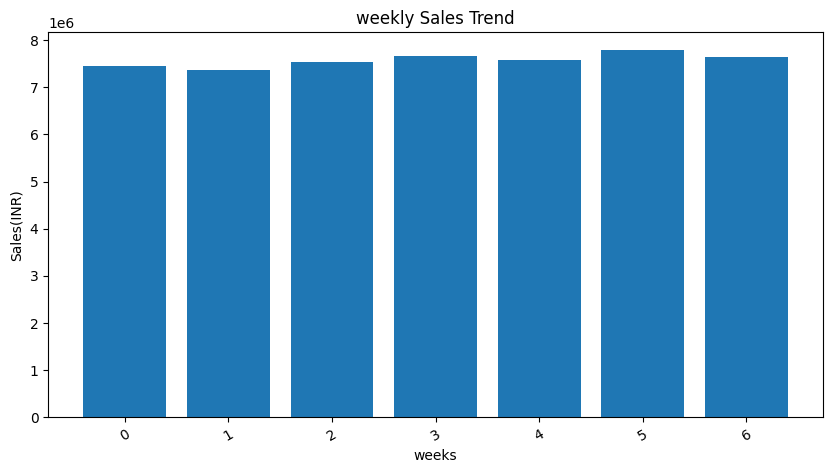

In [25]:
df["week"] = pd.to_datetime(df["Order Date"]).dt.weekday
weekly_revenue = df.groupby("week")["Price (INR)"].sum()
plt.figure(figsize=(10,5))
plt.bar(weekly_revenue.index,weekly_revenue.values)
plt.title("weekly Sales Trend")
plt.xlabel("weeks")
plt.ylabel("Sales(INR)")
plt.xticks(rotation=30)
plt.show()